In [29]:
import pymupdf

# Path to the PDF file
pdf_path = 'data/anes_timeseries_2020_userguidecodebook_20220210.pdf'

# Open the PDF
doc = pymupdf.open(pdf_path)

# Extract text from all pages
full_text = ""
for page_num in range(len(doc)):
    page = doc[page_num]
    full_text += page.get_text()

# Close the document
doc.close()

# Save the text to a file
output_path = 'data/anes_timeseries_2020_userguidecodebook_20220210.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(full_text)

print(f"PDF converted successfully!")
print(f"Text saved to: {output_path}")
print(f"Total characters extracted: {len(full_text)}")
print(f"\nFirst 500 characters:\n{full_text[:500]}")

PDF converted successfully!
Text saved to: data/anes_timeseries_2020_userguidecodebook_20220210.txt
Total characters extracted: 890526

First 500 characters:
ANES 2020 Time Series Study
Full Release
User Guide and Codebook 
February 10, 2022
iii
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 


In [30]:
import re

# Read the text file
with open('data/anes_timeseries_2020_userguidecodebook_20220210.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Split by lines
lines = text.split('\n')

# Extract variables, questions, and value labels
questions = []
skipped_questions = []
i = 0
while i < len(lines):
    line = lines[i].strip()
    
    # Look for variable codes (V followed by digits)
    if re.match(r'^V\d+[a-z]?$', line):
        var_code = line
        
        # Look ahead for "Question" label and extract the question text
        j = i + 1
        question_text = []
        found_question = False
        
        while j < len(lines):
            next_line = lines[j].strip()
            
            # Stop if we hit another variable or a section header
            if re.match(r'^V\d+[a-z]?$', next_line) or \
               next_line in ['Universe', 'Survey Question(s)', 'Interviewer Instruction', 
                            'Variable Note', 'Randomization', 'Display Specification', 'Mode Difference']:
                break
            
            # Stop before "Value Labels"
            if next_line == 'Value Labels':
                break
            
            # Look for "Question" label
            if next_line.lower() == 'question':
                found_question = True
                j += 1
                continue
            
            # Collect question text after "Question" label
            if found_question and next_line:
                question_text.append(next_line)
            
            j += 1
        
        # Now look for "Value Labels" section
        value_labels = []
        if found_question and question_text:
            k = j
            while k < len(lines):
                next_line = lines[k].strip()
                
                # Found Value Labels section
                if next_line == 'Value Labels':
                    k += 1
                    # Collect all label lines until we hit another metadata section or variable
                    while k < len(lines):
                        label_line = lines[k].strip()
                        
                        # Stop at next metadata section or variable
                        if re.match(r'^V\d+[a-z]?$', label_line) or \
                           label_line in ['Universe', 'Survey Question(s)', 'Interviewer Instruction',
                                        'Variable Note', 'Randomization', 'Display Specification', 'Mode Difference', 'Question']:
                            break
                        
                        if label_line:  # Only add non-empty lines
                            value_labels.append(label_line)
                        k += 1
                    break
                
                # Stop if we hit another section without finding Value Labels
                if re.match(r'^V\d+[a-z]?$', next_line) or \
                   next_line in ['Universe', 'Survey Question(s)', 'Interviewer Instruction',
                                'Variable Note', 'Randomization', 'Display Specification', 'Mode Difference']:
                    break
                
                k += 1
        
        # If we found a question, check if it should be included
        if found_question and question_text:
            # Join the question text and clean it up
            full_question = ' '.join(question_text).strip()
            
            # Check if value labels contain "open-end" or "restricted"
            has_open_end = any('open-end' in label.lower() for label in value_labels)
            has_restricted = any('restricted' in label.lower() for label in value_labels)
            
            if has_open_end or has_restricted:
                skipped_questions.append({
                    'variable_code': var_code,
                    'reason': 'open-end' if has_open_end else 'restricted'
                })
            else:
                questions.append({
                    'variable_code': var_code,
                    'question': full_question,
                    'labels': value_labels
                })
    
    i += 1

# Save to file
output_file = 'data/extracted_questions.txt'
with open(output_file, 'w', encoding='utf-8') as f:
    for item in questions:
        f.write(f"{item['variable_code']}\n")
        f.write(f"{item['question']}\n")
        if item['labels']:
            f.write("Value Labels\n")
            for label in item['labels']:
                f.write(f"{label}\n")
        f.write("\n")

print(f"Extracted {len(questions)} questions from the codebook")
print(f"Skipped {len(skipped_questions)} questions (open-end or restricted)")
print(f"Saved to: {output_file}")
print(f"\nFirst 3 examples:")
for i, item in enumerate(questions[:3]):
    print(f"\n{item['variable_code']}")
    print(f"{item['question'][:80]}...")
    if item['labels']:
        print("Value Labels:")
        for label in item['labels'][:3]:
            print(f"  {label}")
        if len(item['labels']) > 3:
            print(f"  ... and {len(item['labels']) - 3} more")

Extracted 1028 questions from the codebook
Skipped 193 questions (open-end or restricted)
Saved to: data/extracted_questions.txt

First 3 examples:

V201001
Would you like to complete this survey in English or Spanish? ¿Quisiera completa...
Value Labels:
  1. English / Ingles
  2. Spanish / Espanol

V201002a
We mailed you a booklet. It was enclosed with the letter inviting you to partici...
Value Labels:
  -1. Inapplicable
  1. R has booklet (paper or emailed)
  2. R does not have paper or email booklet

V201002b
For some of the questions, I’ll share my screen and show you a card with all the...
Value Labels:
  -4. Technical error
  -1. Inapplicable
  1. R sees booklet on screen or PDF
  ... and 1 more


In [31]:
import tiktoken

# Read the extracted questions file
with open('data/extracted_questions.txt', 'r', encoding='utf-8') as f:
    questions_text = f.read()

# Initialize the tokenizer
encoding = tiktoken.get_encoding("cl100k_base")  # This is the encoding for GPT-4 and GPT-3.5

# Count tokens
tokens = encoding.encode(questions_text)
token_count = len(tokens)

print(f"Token count for extracted questions: {token_count:,}")
print(f"File size: {len(questions_text):,} characters")
print(f"Average tokens per character: {token_count / len(questions_text):.3f}")
print(f"\nNumber of questions: {len(questions)}")
print(f"Average tokens per question: {token_count / len(questions):.1f}")

Token count for extracted questions: 84,765
File size: 315,077 characters
Average tokens per character: 0.269

Number of questions: 1028
Average tokens per question: 82.5


In [85]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
raw_csv_path = Path("data/anes_timeseries_2020_csv_20220210.csv")
clean_csv_path = Path("data/policy_clean.csv")

print(f"Loading {raw_csv_path} ...")
df = pd.read_csv(raw_csv_path)

# Missing codes
MISSING = {-9, -8, -7, -6, -5, -4, -3, -2, -1, 99}
MISSING_THERM = {-9, -8, -7, -6, -5, -4, 998, 999}

def get_first(cols, exclude=MISSING):
    """Return first existing column in df (with missing codes -> NaN), else all-NaN series."""
    for c in cols:
        if c in df.columns:
            return df[c].replace(exclude, np.nan)
    return pd.Series(np.nan, index=df.index)

# Build policy columns with succinct names (<= 15 chars), except the three specified to remain as-is
policy = {}

# Keep these names exactly as requested
policy["ideology_7pt"] = get_first(["V201200"])
policy["ideology_3pt_signed"] = policy["ideology_7pt"].map({1: 1, 2: 1, 3: 1, 4: 0, 5: -1, 6: -1, 7: -1})
policy["party_id_signed"] = get_first(["V201228"]).map({1: -1, 2: 1, 3: 0, 5: 0, 0: 0})

# Immigration / rights / institutions
policy["imm_unauth"]   = get_first(["V201417"])        
policy["birthright"]   = get_first(["V201420x"])
policy["paid_leave"]   = get_first(["V201405x"])
policy["trump_corr"]   = get_first(["V201382x"])
policy["journ_access"] = get_first(["V201375x"])

# Guns / crime / courts
policy["gun_bkg_chk"]  = get_first(["V202341x"])
policy["illeg_child"]  = get_first(["V201423x"])
policy["death_pen"]    = get_first(["V201345x"])
policy["abortion"]     = get_first(["V201336"], exclude={-9, -8, 5})
policy["scotus_abort"] = get_first(["V201342x"])
policy["ar_ban"]       = get_first(["V202344x"])

# Elections / economy
policy["econ_now"]     = get_first(["V201324"])
policy["voter_id"]     = get_first(["V201359x"])
policy["felon_vote"]   = get_first(["V201362x"])

# Health / education / spending
policy["vax_school"]   = get_first(["V202331x"])
policy["spend_border"] = get_first(["V201308x"])
policy["spend_welfare"]= get_first(["V201314x"])        
policy["spend_poor"]   = get_first(["V201320x"])
policy["spend_school"] = get_first(["V201305x"])

# Governance / social issues
policy["checks_power"] = get_first(["V201367"])
policy["border_wall"]  = get_first(["V201426x"])
policy["trans_bath"]   = get_first(["V201411x"])
policy["police_force"] = get_first(["V202351"])
policy["assist_black"] = get_first(["V201258"])
policy["job_guar"]     = get_first(["V201255"])
policy["govt_health"]  = get_first(["V201252"])
policy["obamacare"]    = get_first(["V202328x"])

# Spending / unrest / climate / foreign
policy["svc_spend"]    = get_first(["V201246"])
policy["def_spend"]    = get_first(["V201249"])
policy["urban_unrest"] = get_first(["V201429"])
policy["clim_imp"]     = get_first(["V202333"])
policy["rus_interf"]   = get_first(["V201428"])

# Feeling thermometers
policy["ft_trans"]     = get_first(["V202172"], exclude=MISSING_THERM)
policy["ft_union"]     = get_first(["V202162"], exclude=MISSING_THERM)
policy["ft_fem"]       = get_first(["V202160"], exclude=MISSING_THERM)
policy["ft_sci"]       = get_first(["V202173"], exclude=MISSING_THERM)
policy["ft_police"]    = get_first(["V202171"], exclude=MISSING_THERM)

# Environment / guns / military
policy["env_bus"]      = get_first(["V201262"])        
policy["ghg_emiss"]    = get_first(["V202336x"])
policy["gun_imp"]      = get_first(["V202338"])
policy["mil_force"]    = get_first(["V201350"])

# Assemble clean DataFrame
clean = pd.DataFrame(policy)

# Diagnostics
missing_in_file = [k for k, s in policy.items() if s.isna().all()]
if missing_in_file:
    print("Warning: missing raw columns for:", missing_in_file)

too_long = [c for c in clean.columns if c not in {"party_id_signed", "ideology_7pt", "ideology_3pt_signed"} and len(c) > 15]
if too_long:
    raise ValueError(f"These column names exceed 15 characters: {too_long}")

non_null_counts = clean.notna().sum().sort_values(ascending=False)
print("Non-null counts per column:\n", non_null_counts)

clean.to_csv(clean_csv_path, index=False)
print(f"Saved cleaned policy dataset to {clean_csv_path}")


Loading data/anes_timeseries_2020_csv_20220210.csv ...


/scratch/local/jobs/44131329/ipykernel_1196290/359386984.py:10: DtypeWarning: Columns (15,17,18,19,21,22,23,25,26,27,29,30,31,33,34,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(raw_csv_path)


Non-null counts per column:
 econ_now               8259
voter_id               8256
felon_vote             8251
spend_school           8247
checks_power           8243
paid_leave             8242
border_wall            8240
party_id_signed        8231
spend_border           8227
spend_poor             8225
birthright             8225
mil_force              8222
journ_access           8214
spend_welfare          8213
scotus_abort           8208
imm_unauth             8197
trump_corr             8195
rus_interf             8155
illeg_child            8131
death_pen              8113
trans_bath             7967
abortion               7900
urban_unrest           7713
assist_black           7403
ft_police              7388
gun_bkg_chk            7387
vax_school             7384
clim_imp               7383
obamacare              7382
ar_ban                 7381
gun_imp                7378
ft_sci                 7367
ghg_emiss              7364
police_force           7355
govt_health        

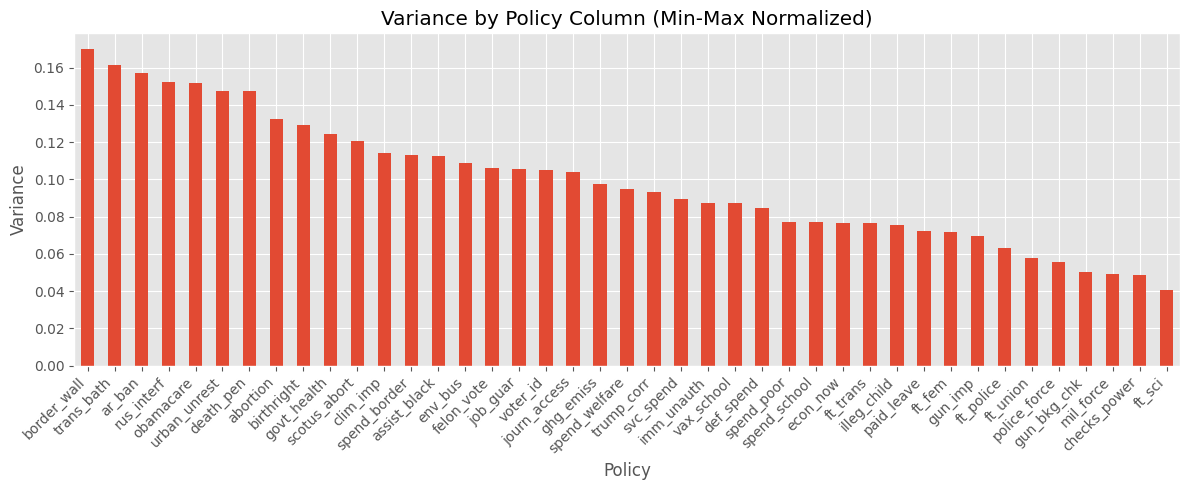

In [82]:
import matplotlib.pyplot as plt

# Load cleaned policy data
clean = pd.read_csv("data/policy_clean.csv")

# Define columns to exclude from normalization (ideology and partisanship)
exclude_cols = ['party_id_signed', 'ideology_7pt', 'ideology_3pt_signed']

# Get policy columns (exclude ideology/partisan columns)
policy_cols = [col for col in clean.columns if col not in exclude_cols]

# Min-max normalize policy columns only
col_min = clean[policy_cols].min(skipna=True)
col_max = clean[policy_cols].max(skipna=True)
col_range = col_max - col_min
safe_range = col_range.replace(0, np.nan)

clean_normalized = clean.copy()
clean_normalized[policy_cols] = (clean[policy_cols] - col_min) / safe_range

# Calculate variance for each policy
variance = {col: clean_normalized[col].var(skipna=True) for col in policy_cols}
variance_sorted = dict(sorted(variance.items(), key=lambda x: x[1], reverse=True))

# Plot 1: Variance
plt.figure(figsize=(12, 5))
pd.Series(variance_sorted).plot(kind='bar')
plt.title('Variance by Policy Column (Min-Max Normalized)')
plt.ylabel('Variance')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

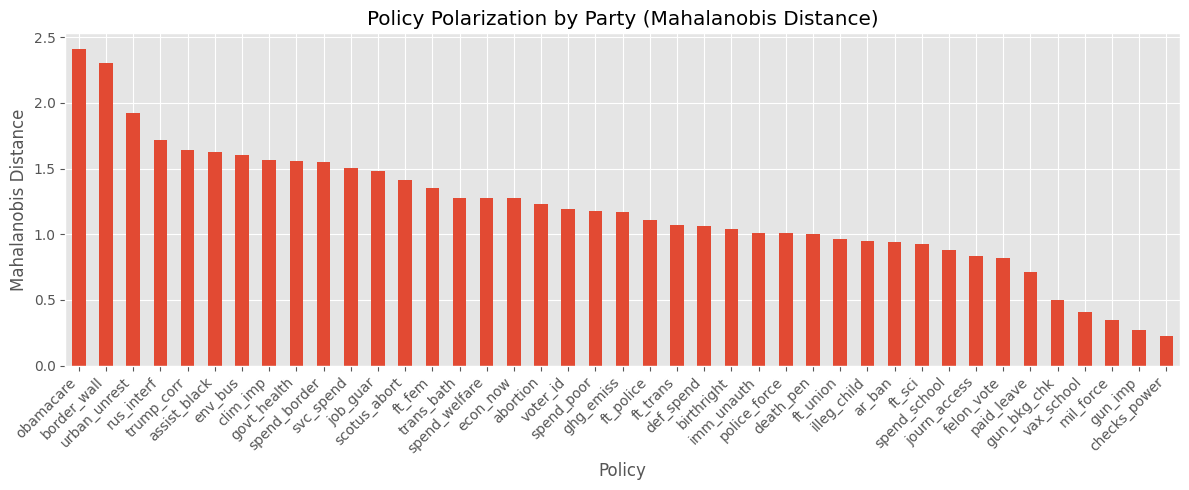


Top 10 Most Polarized Policies (Mahalanobis):
1. obamacare: 2.4081
2. border_wall: 2.3030
3. urban_unrest: 1.9199
4. rus_interf: 1.7166
5. trump_corr: 1.6373
6. assist_black: 1.6231
7. env_bus: 1.5994
8. clim_imp: 1.5654
9. govt_health: 1.5561
10. spend_border: 1.5508


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Calculate polarization by party for each policy (using Mahalanobis Distance)
polarization = {}

for col in policy_cols:
    # Get data for each party (drop NaNs to ensure valid variance calc)
    dem_data = clean_normalized[col][clean['party_id_signed'] == -1].dropna()
    rep_data = clean_normalized[col][clean['party_id_signed'] == 1].dropna()
    
    # We need at least 2 points to calculate variance
    if len(dem_data) < 2 or len(rep_data) < 2:
        polarization[col] = 0.0
        continue
    
    # 1. Calculate Means
    mu_d = dem_data.mean()
    mu_r = rep_data.mean()
    
    # 2. Calculate Pooled Variance (1D equivalent of Pooled Covariance Matrix)
    var_d = dem_data.var()
    var_r = rep_data.var()
    
    # Average the variances (consistent with your LLM pipeline's `(cov_d + cov_r) / 2`)
    pool_var = (var_d + var_r) / 2
    
    # Regularization to prevent division by zero (same as your `+ np.eye * 1e-6`)
    pool_var += 1e-6 
    
    # 3. Calculate Mahalanobis Distance
    # Formula for 1D: |Mean_Diff| / sqrt(Pooled_Variance)
    polarization[col] = abs(mu_r - mu_d) / np.sqrt(pool_var)

# Sort polarization for plotting
polarization_sorted = dict(sorted(polarization.items(), key=lambda x: x[1], reverse=True))

# Plot 2: Polarization
plt.figure(figsize=(12, 5))
pd.Series(polarization_sorted).plot(kind='bar')
plt.title('Policy Polarization by Party (Mahalanobis Distance)')
plt.ylabel('Mahalanobis Distance')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Polarized Policies (Mahalanobis):")
for i, (policy, value) in enumerate(list(polarization_sorted.items())[:10], 1):
    print(f"{i}. {policy}: {value:.4f}")

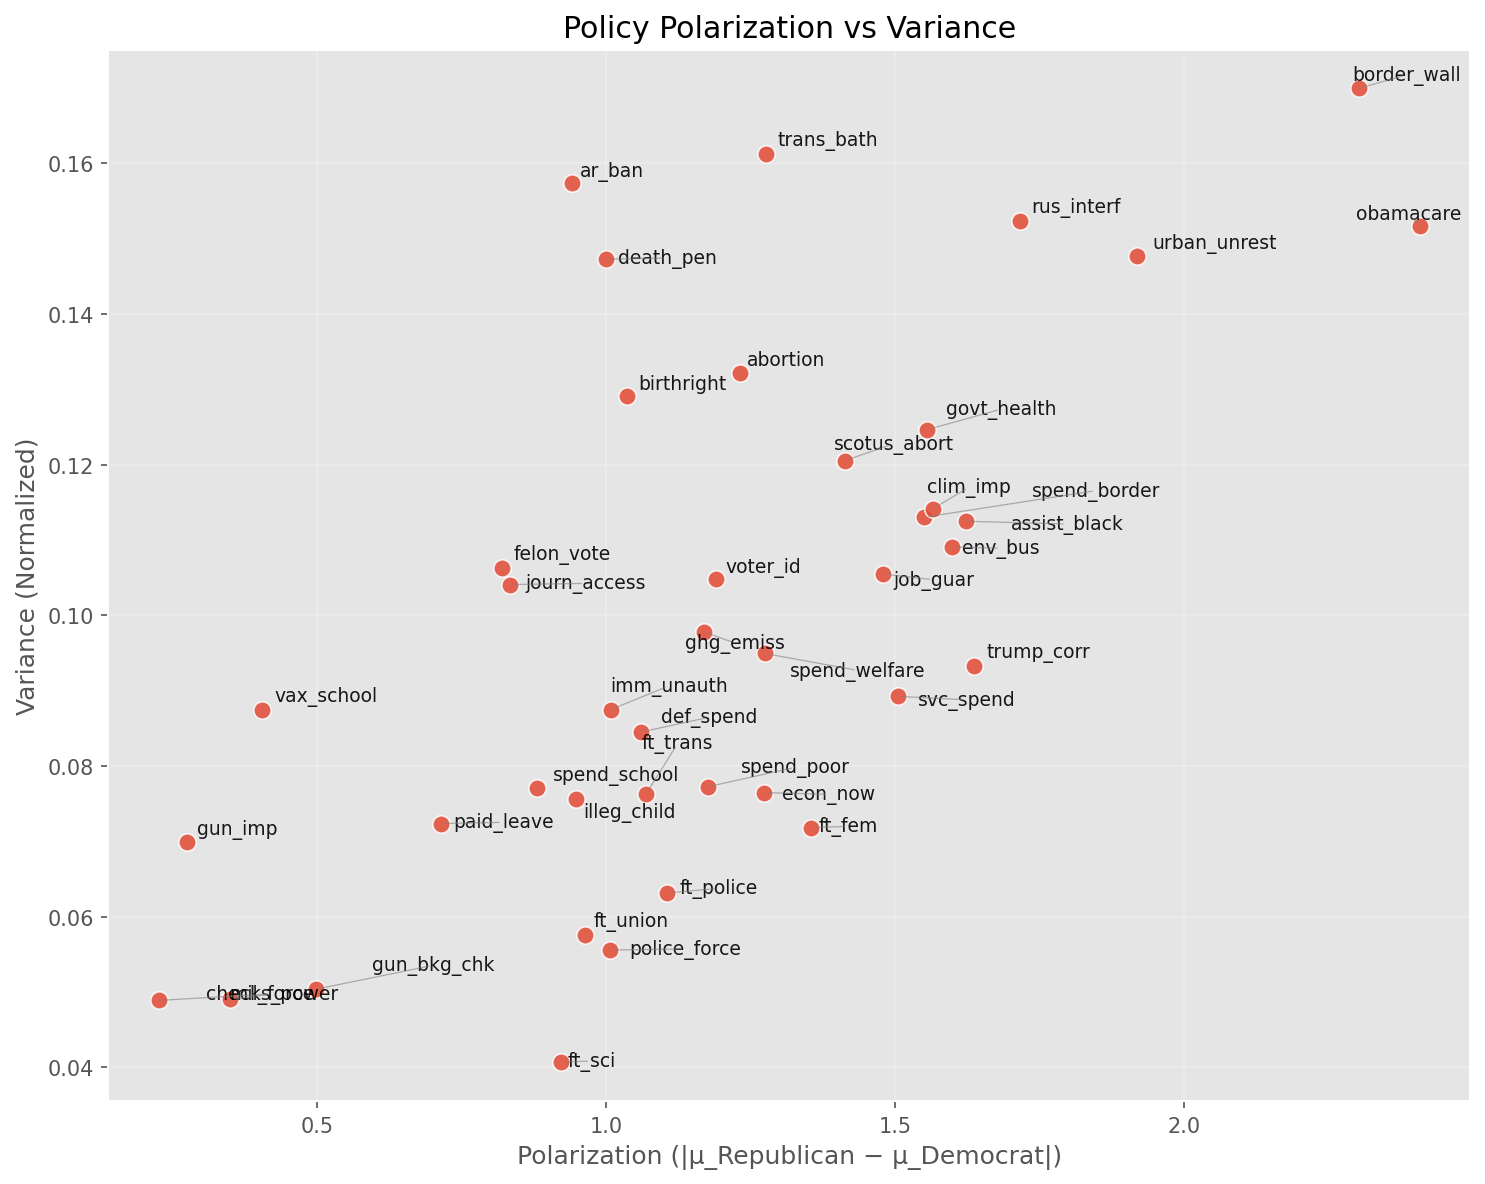

In [84]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# Extract x and y values
x_values = [polarization[p] for p in policy_cols]
y_values = [variance[p] for p in policy_cols]

# Scatter plot
ax.scatter(
    x_values,
    y_values,
    s=70,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
)

# Create text objects (start exactly at the point)
texts = []
for p, x, y in zip(policy_cols, x_values, y_values):
    texts.append(
        ax.text(
            x,
            y,
            p,
            fontsize=9,
            alpha=0.9,
        )
    )

ax.set_xlabel("Polarization (|μ_Republican − μ_Democrat|)")
ax.set_ylabel("Variance (Normalized)")
ax.set_title("Policy Polarization vs Variance")
ax.grid(True, alpha=0.25)

# Add modest padding
x_pad = 0.04 * (max(x_values) - min(x_values) or 1)
y_pad = 0.04 * (max(y_values) - min(y_values) or 1)
ax.set_xlim(min(x_values) - x_pad, max(x_values) + x_pad)
ax.set_ylim(min(y_values) - y_pad, max(y_values) + y_pad)

# Strongly constrained adjustment
adjust_text(
    texts,
    x=x_values,
    y=y_values,
    ax=ax,

    # Keep labels close
    expand_points=(1.05, 1.1),
    expand_text=(1.05, 1.1),

    # Weak repulsion forces
    force_points=(0.03, 0.1),
    force_text=(0.03, 0.1),

    # Explicit attraction back to the point
    pull_points=(0.6, 0.6),
    pull_text=(0.6, 0.6),

    # Limit iterations to prevent drift
    lim=100,

    arrowprops=dict(
        arrowstyle="-",
        color="grey",
        lw=0.6,
        alpha=0.6,
    ),
)

fig.tight_layout()
plt.show()
